# TwinCar - EfficientNet-B0 v1 Evaluation Notebook

This notebook evaluates the trained **EfficientNet-B0 v1 / baseline** model on the held-out test set.

It uses the same evaluation style as the other model evaluation notebooks:

- accuracy
- top-5 accuracy
- precision
- recall
- F1-score
- balanced accuracy
- test loss
- make-level accuracy
- make + model accuracy
- readable confusion matrices
- top confusion pairs
- confidence/error analysis
- misclassified examples
- final summary CSV for README and presentation

Use this notebook after running `03a_efficientnet_b0_v1.ipynb` and saving a model checkpoint.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
import re
import json
import time
import shutil
import subprocess
import sys
import importlib.util
from pathlib import Path
from collections import Counter

if importlib.util.find_spec("datasets") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "datasets"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from datasets import load_dataset
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


## Configuration

This notebook is configured for the **EfficientNet-B0 v1 baseline**.

Important detail: the original `03a_efficientnet_b0_v1.ipynb` saves its checkpoint directly in:

```python
/content/drive/MyDrive/twincar/models/
```

This evaluation notebook also checks optional subfolders such as:

```python
/content/drive/MyDrive/twincar/models/efficientnet_b0_v1/
```

so it can work even if the project is later reorganized.


In [3]:
PROJECT_DIR = Path("/content/drive/MyDrive/twincar")
DATA_DIR = Path("/content/twincar_data")
STANFORD_CACHE = PROJECT_DIR / "stanford_cars_cache"
METADATA_PATH = PROJECT_DIR / "data" / "stanford_metadata.csv"

MODEL_NAME = "efficientnet_b0_v1"
MODEL_DISPLAY_NAME = "EfficientNet-B0 v1"

CANDIDATE_MODEL_DIRS = [
    PROJECT_DIR / "models" / "efficientnet_b0_v1",
    PROJECT_DIR / "models" / "efficientnet_b0",
    PROJECT_DIR / "models",
]

CANDIDATE_CHECKPOINT_NAMES = [
    "best_model_by_val_top1.pt",
    "best_model_by_val_acc.pt",
    "best_model_by_val_loss.pt",
    "best_model.pt",
    "last_checkpoint.pt",
]

def find_checkpoint():
    checked_paths = []

    for model_dir in CANDIDATE_MODEL_DIRS:
        for checkpoint_name in CANDIDATE_CHECKPOINT_NAMES:
            checkpoint_path = model_dir / checkpoint_name
            checked_paths.append(checkpoint_path)

            if checkpoint_path.exists():
                return model_dir, checkpoint_path, checkpoint_name, checked_paths

    expected = "\n".join(str(p) for p in checked_paths)

MODEL_DIR, MODEL_PATH, CHECKPOINT_NAME, CHECKED_PATHS = find_checkpoint()

REPORTS_DIR = PROJECT_DIR / "reports" / MODEL_NAME
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("METADATA_PATH:", METADATA_PATH)
print("MODEL_DIR:", MODEL_DIR)
print("MODEL_PATH:", MODEL_PATH)
print("CHECKPOINT_NAME:", CHECKPOINT_NAME)
print("REPORTS_DIR:", REPORTS_DIR)


PROJECT_DIR: /content/drive/MyDrive/twincar
DATA_DIR: /content/twincar_data
METADATA_PATH: /content/drive/MyDrive/twincar/data/stanford_metadata.csv
MODEL_DIR: /content/drive/MyDrive/twincar/models
MODEL_PATH: /content/drive/MyDrive/twincar/models/best_model.pt
CHECKPOINT_NAME: best_model.pt
REPORTS_DIR: /content/drive/MyDrive/twincar/reports/efficientnet_b0_v1


## Load training configuration

The v1 notebook saved `train_config.json` in the model folder. If it is not found, this notebook uses safe defaults from the original v1 experiment:

- image size: 224
- dropout: 0.3
- batch size: 32
- ImageNet normalization


In [4]:
def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

possible_config_paths = [
    MODEL_DIR / "train_config.json",
    PROJECT_DIR / "models" / "train_config.json",
    PROJECT_DIR / "models" / MODEL_NAME / "train_config.json",
]

CONFIG_PATH = next((p for p in possible_config_paths if p.exists()), None)

if CONFIG_PATH is not None:
    train_config = load_json(CONFIG_PATH)
    print("Loaded train_config:", CONFIG_PATH)
else:
    train_config = {
        "model": MODEL_NAME,
        "num_classes": 195,
        "img_size": 224,
        "batch_size": 32,
        "dropout": 0.3,
        "imagenet_mean": [0.485, 0.456, 0.406],
        "imagenet_std": [0.229, 0.224, 0.225],
    }
    print("train_config.json not found. Using default v1 config.")

IMG_SIZE = int(train_config.get("img_size", 224))
BATCH_SIZE = int(train_config.get("batch_size", 32))
NUM_WORKERS = 2
TOP_K = 5
DROPOUT = float(train_config.get("dropout", 0.3))

IMAGENET_MEAN = train_config.get("imagenet_mean", [0.485, 0.456, 0.406])
IMAGENET_STD = train_config.get("imagenet_std", [0.229, 0.224, 0.225])

print("IMG_SIZE:", IMG_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)
print("DROPOUT:", DROPOUT)
print("TOP_K:", TOP_K)


Loaded train_config: /content/drive/MyDrive/twincar/models/train_config.json
IMG_SIZE: 224
BATCH_SIZE: 32
DROPOUT: 0.3
TOP_K: 5


## Restore / load the test set

The evaluation expects ImageFolder structure:

```text
/content/twincar_data/test/class_name/image.jpg
```

If the test folder does not exist in the current Colab runtime, this notebook rebuilds it from the Hugging Face Stanford Cars dataset using `stanford_metadata.csv`.


In [5]:
IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def sanitize(name):
    """Use the same class folder naming rule as the training notebook."""
    return str(name).replace(" ", "_").replace("/", "-")

def get_class_name(row):
    if "class_name" in row and pd.notna(row["class_name"]):
        return row["class_name"]
    return row["car_name"]

def looks_like_imagefolder_root(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False

    class_dirs = [p for p in path.iterdir() if p.is_dir()]
    if len(class_dirs) == 0:
        return False

    for class_dir in class_dirs[:20]:
        has_image = any(
            f.suffix.lower() in IMG_EXTENSIONS
            for f in class_dir.rglob("*")
        )
        if has_image:
            return True

    return False

TEST_DIR = DATA_DIR / "test"

if looks_like_imagefolder_root(TEST_DIR):
    print("Using existing local test folder:", TEST_DIR)
else:
    print("Local test folder not found or not valid. Rebuilding test set...")

    metadata = pd.read_csv(METADATA_PATH)
    test_df = metadata[metadata["split"] == "test"].reset_index(drop=True)

    if TEST_DIR.exists():
        shutil.rmtree(TEST_DIR)
    TEST_DIR.mkdir(parents=True, exist_ok=True)

    hf_dataset = load_dataset("naufalso/stanford_cars", cache_dir=str(STANFORD_CACHE))

    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Restoring test images"):
        class_dir = TEST_DIR / sanitize(get_class_name(row))
        class_dir.mkdir(parents=True, exist_ok=True)

        out_path = class_dir / f"{int(row['hf_idx'])}.jpg"

        img = hf_dataset["test"][int(row["hf_idx"])]["image_path"]
        img.save(out_path)

    del hf_dataset
    print("Test set restored to:", TEST_DIR)

print("TEST_DIR:", TEST_DIR)
print("Exists:", TEST_DIR.exists())


Local test folder not found or not valid. Rebuilding test set...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/614 [00:00<?, ?B/s]

Restoring test images:   0%|          | 0/8000 [00:00<?, ?it/s]

Test set restored to: /content/twincar_data/test
TEST_DIR: /content/twincar_data/test
Exists: True


## Test preprocessing

The test set must use deterministic preprocessing, not random augmentation.

This should match the v1 validation/test preprocessing:

```python
Resize(256)
CenterCrop(224)
Normalize(ImageNet mean/std)
```


In [6]:
val_test_transforms = transforms.Compose([
    transforms.Resize(256 if IMG_SIZE == 224 else int(IMG_SIZE * 1.15)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_dataset = datasets.ImageFolder(
    root=str(TEST_DIR),
    transform=val_test_transforms,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
)

print("Test images:", len(test_dataset))
print("Test classes:", len(test_dataset.classes))
print("Batches:", len(test_loader))
print("Example class:", test_dataset.classes[0])


Test images: 8000
Test classes: 195
Batches: 250
Example class: AM_General_Hummer_SUV_2000


## Load label mapping

For reliable evaluation, the class-to-index mapping used during training must match the mapping used by `ImageFolder` during evaluation.

The v1 notebook saved its label map as:

```python
/content/drive/MyDrive/twincar/data/imagefolder_label_map.json
```

This file maps model output index to class folder name.


In [7]:
possible_idx_to_class_paths = [
    MODEL_DIR / "idx_to_class.json",
    MODEL_DIR / "imagefolder_label_map.json",
    PROJECT_DIR / "data" / "idx_to_class.json",
    PROJECT_DIR / "data" / "imagefolder_label_map.json",
    DATA_DIR / "imagefolder_label_map.json",
]

possible_class_to_idx_paths = [
    MODEL_DIR / "class_to_idx.json",
    PROJECT_DIR / "data" / "class_to_idx.json",
]

IDX_TO_CLASS_PATH = next((p for p in possible_idx_to_class_paths if p.exists()), None)
CLASS_TO_IDX_PATH = next((p for p in possible_class_to_idx_paths if p.exists()), None)

if IDX_TO_CLASS_PATH is not None:
    idx_to_class_raw = load_json(IDX_TO_CLASS_PATH)
    idx_to_class = {int(k): v for k, v in idx_to_class_raw.items()}
    print("Loaded idx_to_class:", IDX_TO_CLASS_PATH)
else:
    print("idx_to_class file not found. Falling back to test_dataset.classes.")
    idx_to_class = {idx: class_name for idx, class_name in enumerate(test_dataset.classes)}

if CLASS_TO_IDX_PATH is not None:
    class_to_idx = {k: int(v) for k, v in load_json(CLASS_TO_IDX_PATH).items()}
    print("Loaded class_to_idx:", CLASS_TO_IDX_PATH)
else:
    class_to_idx = {class_name: idx for idx, class_name in idx_to_class.items()}
    print("class_to_idx file not found. Reconstructed it from idx_to_class.")

num_classes = len(idx_to_class)

print("Class mapping OK.")
print("Number of classes:", num_classes)

Loaded idx_to_class: /content/drive/MyDrive/twincar/data/imagefolder_label_map.json
class_to_idx file not found. Reconstructed it from idx_to_class.
Class mapping OK.
Number of classes: 195


## Build EfficientNet-B0 v1 model

This matches the classifier used in `03a_efficientnet_b0_v1.ipynb`:

```python
model = efficientnet_b0(pretrained ImageNet during training)
model.classifier = Dropout(0.3) + Linear(num_classes)
```

For evaluation, we instantiate the same architecture with `weights=None` and then load the saved checkpoint.


In [8]:
def build_efficientnet_b0_v1(num_classes, dropout=0.3):
    model = models.efficientnet_b0(weights=None)

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features, num_classes),
    )

    return model

model = build_efficientnet_b0_v1(num_classes=num_classes, dropout=DROPOUT)

print(model.__class__.__name__)
print(model.classifier)


EfficientNet
Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1280, out_features=195, bias=True)
)


In [9]:
def clean_state_dict_keys(state_dict):
    if not any(k.startswith("module.") for k in state_dict.keys()):
        return state_dict
    return {k.replace("module.", "", 1): v for k, v in state_dict.items()}

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
else:
    state_dict = checkpoint

state_dict = clean_state_dict_keys(state_dict)
model.load_state_dict(state_dict)
model = model.to(DEVICE)
model.eval()

model_size_mb = MODEL_PATH.stat().st_size / 1e6

print(f"Loaded checkpoint: {MODEL_PATH}")
print(f"Model file size: {model_size_mb:.2f} MB")
print("Model device:", next(model.parameters()).device)


Loaded checkpoint: /content/drive/MyDrive/twincar/models/best_model.pt
Model file size: 17.33 MB
Model device: cuda:0


## Label parsing: make, make + model, and year

Stanford Cars-style labels often look like this:

```text
Audi S4 Sedan 2012
BMW X5 SUV 2007
AM General Hummer SUV 2000
```

For readable evaluation we create three label levels:

1. **exact class**: make + model + body style + year
2. **make_model**: make + model/body style, without year
3. **make**: brand only

This helps because a 195-class confusion matrix is too large to read.


In [10]:
KNOWN_MAKES = [
    "AM General", "Aston Martin", "Land Rover", "Mercedes-Benz", "Rolls-Royce",
    "Acura", "Audi", "BMW", "Bentley", "Bugatti", "Buick", "Cadillac",
    "Chevrolet", "Chrysler", "Daewoo", "Dodge", "Eagle", "FIAT", "Ferrari",
    "Fisker", "Ford", "GMC", "Geo", "HUMMER", "Honda", "Hyundai", "Infiniti",
    "Isuzu", "Jaguar", "Jeep", "Lamborghini", "Lincoln", "MINI", "Maybach",
    "Mazda", "McLaren", "Mitsubishi", "Nissan", "Plymouth", "Porsche", "Ram",
    "Scion", "Spyker", "Suzuki", "Tesla", "Toyota", "Volkswagen", "Volvo", "smart",
]
KNOWN_MAKES = sorted(KNOWN_MAKES, key=len, reverse=True)

def clean_class_name(class_name):
    return str(class_name).replace("_", " ").strip()

def parse_vehicle_label(class_name):
    label = clean_class_name(class_name)

    year_match = re.search(r"\b(19|20)\d{2}\b$", label)
    year = year_match.group(0) if year_match else None
    without_year = re.sub(r"\s+\b(19|20)\d{2}\b$", "", label).strip()

    make = None
    for candidate in KNOWN_MAKES:
        if without_year == candidate or without_year.startswith(candidate + " "):
            make = candidate
            break

    if make is None:
        parts = without_year.split()
        make = parts[0] if parts else "unknown"

    model_part = without_year[len(make):].strip()
    if not model_part:
        model_part = "unknown_model"

    make_model = f"{make} {model_part}".strip()

    return {
        "full_label": label,
        "make": make,
        "model": model_part,
        "make_model": make_model,
        "year": year,
    }

# Quick sanity check
for example in list(idx_to_class.values())[:5]:
    print(example, "->", parse_vehicle_label(example))


AM_General_Hummer_SUV_2000 -> {'full_label': 'AM General Hummer SUV 2000', 'make': 'AM General', 'model': 'Hummer SUV', 'make_model': 'AM General Hummer SUV', 'year': '2000'}
Acura_Integra_Type_R_2001 -> {'full_label': 'Acura Integra Type R 2001', 'make': 'Acura', 'model': 'Integra Type R', 'make_model': 'Acura Integra Type R', 'year': '2001'}
Acura_RL_Sedan_2012 -> {'full_label': 'Acura RL Sedan 2012', 'make': 'Acura', 'model': 'RL Sedan', 'make_model': 'Acura RL Sedan', 'year': '2012'}
Acura_TL_Sedan_2012 -> {'full_label': 'Acura TL Sedan 2012', 'make': 'Acura', 'model': 'TL Sedan', 'make_model': 'Acura TL Sedan', 'year': '2012'}
Acura_TL_Type-S_2008 -> {'full_label': 'Acura TL Type-S 2008', 'make': 'Acura', 'model': 'TL Type-S', 'make_model': 'Acura TL Type-S', 'year': '2008'}


## Run evaluation

This cell performs inference on the full test set and stores predictions.

Outputs include:

- true class index
- predicted class index
- confidence of the predicted class
- top-k predictions
- file path


In [11]:
def evaluate(model, loader, top_k=5):
    model.eval()

    all_true = []
    all_pred = []
    all_conf = []
    all_topk_indices = []
    all_topk_probs = []

    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    n_seen = 0

    if DEVICE.type == "cuda":
        try:
            warm_images, _ = next(iter(loader))
            warm_images = warm_images.to(DEVICE, non_blocking=True)

            with torch.inference_mode():
                for _ in range(2):
                    with torch.amp.autocast("cuda", enabled=True):
                        _ = model(warm_images)

            torch.cuda.synchronize()
        except Exception as e:
            print("Warm-up skipped:", e)

    start_time = time.time()

    with torch.inference_mode():
        for images, labels in tqdm(loader, desc="Evaluating test set"):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
                logits = model(images)
                loss = criterion(logits, labels)

            probs = torch.softmax(logits, dim=1)
            conf, preds = probs.max(dim=1)

            k = min(top_k, probs.size(1))
            topk_probs, topk_indices = probs.topk(k, dim=1)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            n_seen += batch_size

            all_true.extend(labels.cpu().numpy().tolist())
            all_pred.extend(preds.cpu().numpy().tolist())
            all_conf.extend(conf.cpu().numpy().tolist())
            all_topk_indices.extend(topk_indices.cpu().numpy().tolist())
            all_topk_probs.extend(topk_probs.cpu().numpy().tolist())

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start_time

    return {
        "y_true": np.array(all_true),
        "y_pred": np.array(all_pred),
        "confidence": np.array(all_conf),
        "topk_indices": np.array(all_topk_indices),
        "topk_probs": np.array(all_topk_probs),
        "test_loss": total_loss / n_seen,
        "elapsed_seconds": elapsed,
        "images_per_second": n_seen / elapsed if elapsed > 0 else None,
    }

results = evaluate(model, test_loader, top_k=TOP_K)

print(f"Test loss: {results['test_loss']:.4f}")
print(f"Evaluated {len(results['y_true'])} images in {results['elapsed_seconds']:.1f} seconds")
print(f"Speed: {results['images_per_second']:.2f} images/second")


Evaluating test set:   0%|          | 0/250 [00:00<?, ?it/s]

Test loss: 0.8874
Evaluated 8000 images in 67.5 seconds
Speed: 118.57 images/second


## Create predictions table

This table is useful because it lets us inspect individual errors, confidence, and class-level aggregation.


In [12]:
y_true = results["y_true"]
y_pred = results["y_pred"]
confidence = results["confidence"]
topk_indices = results["topk_indices"]
topk_probs = results["topk_probs"]

rows = []

for i, (true_idx, pred_idx, conf) in enumerate(zip(y_true, y_pred, confidence)):
    image_path, _ = test_dataset.samples[i]

    true_class = idx_to_class[int(true_idx)]
    pred_class = idx_to_class[int(pred_idx)]

    true_parsed = parse_vehicle_label(true_class)
    pred_parsed = parse_vehicle_label(pred_class)

    topk_labels = [idx_to_class[int(idx)] for idx in topk_indices[i]]
    topk_prob_values = [float(p) for p in topk_probs[i]]

    rows.append({
        "image_path": image_path,
        "true_idx": int(true_idx),
        "pred_idx": int(pred_idx),
        "true_class": clean_class_name(true_class),
        "pred_class": clean_class_name(pred_class),
        "correct_exact": bool(true_idx == pred_idx),
        "confidence": float(conf),

        "true_make": true_parsed["make"],
        "pred_make": pred_parsed["make"],
        "correct_make": true_parsed["make"] == pred_parsed["make"],

        "true_make_model": true_parsed["make_model"],
        "pred_make_model": pred_parsed["make_model"],
        "correct_make_model": true_parsed["make_model"] == pred_parsed["make_model"],

        "true_year": true_parsed["year"],
        "pred_year": pred_parsed["year"],
        "correct_year": true_parsed["year"] == pred_parsed["year"],

        "topk_labels": json.dumps([clean_class_name(x) for x in topk_labels]),
        "topk_probs": json.dumps(topk_prob_values),
        "true_in_topk": bool(int(true_idx) in [int(x) for x in topk_indices[i]]),
    })

predictions_df = pd.DataFrame(rows)

predictions_path = REPORTS_DIR / "predictions.csv"
predictions_df.to_csv(predictions_path, index=False)

print("Saved predictions to:", predictions_path)
display(predictions_df.head())


Saved predictions to: /content/drive/MyDrive/twincar/reports/efficientnet_b0_v1/predictions.csv


,image_path,true_idx,pred_idx,true_class,pred_class,correct_exact,confidence,true_make,pred_make,correct_make,true_make_model,pred_make_model,correct_make_model,true_year,pred_year,correct_year,topk_labels,topk_probs,true_in_topk
0,/content/twincar_data/test/AM_General_Hummer_S...,0,0,AM General Hummer SUV 2000,AM General Hummer SUV 2000,True,0.346924,AM General,AM General,True,AM General Hummer SUV,AM General Hummer SUV,True,2000,2000,True,"[""AM General Hummer SUV 2000"", ""Jeep Wrangler ...","[0.346923828125, 0.11126708984375, 0.052398681...",True
1,/content/twincar_data/test/AM_General_Hummer_S...,0,0,AM General Hummer SUV 2000,AM General Hummer SUV 2000,True,0.983398,AM General,AM General,True,AM General Hummer SUV,AM General Hummer SUV,True,2000,2000,True,"[""AM General Hummer SUV 2000"", ""Spyker C8 Coup...","[0.9833984375, 0.00047469139099121094, 0.00032...",True
2,/content/twincar_data/test/AM_General_Hummer_S...,0,0,AM General Hummer SUV 2000,AM General Hummer SUV 2000,True,0.633301,AM General,AM General,True,AM General Hummer SUV,AM General Hummer SUV,True,2000,2000,True,"[""AM General Hummer SUV 2000"", ""HUMMER H3T Cre...","[0.63330078125, 0.0257415771484375, 0.00596618...",True
3,/content/twincar_data/test/AM_General_Hummer_S...,0,0,AM General Hummer SUV 2000,AM General Hummer SUV 2000,True,0.695801,AM General,AM General,True,AM General Hummer SUV,AM General Hummer SUV,True,2000,2000,True,"[""AM General Hummer SUV 2000"", ""Ford F-450 Sup...","[0.69580078125, 0.01409149169921875, 0.0094223...",True
4,/content/twincar_data/test/AM_General_Hummer_S...,0,0,AM General Hummer SUV 2000,AM General Hummer SUV 2000,True,0.856934,AM General,AM General,True,AM General Hummer SUV,AM General Hummer SUV,True,2000,2000,True,"[""AM General Hummer SUV 2000"", ""Rolls-Royce Ph...","[0.85693359375, 0.004993438720703125, 0.003067...",True


## Main metrics: accuracy, precision, recall, F1-score

In [13]:
def safe_metric(metric_fn, y_true_values, y_pred_values, **kwargs):
    return metric_fn(y_true_values, y_pred_values, zero_division=0, **kwargs)

exact_top1_accuracy = accuracy_score(y_true, y_pred)
exact_top5_accuracy = predictions_df["true_in_topk"].mean()

year_rows = predictions_df[predictions_df["true_year"].notna()]
year_accuracy = year_rows["correct_year"].mean() if len(year_rows) else np.nan

metrics = {
    "model_name": MODEL_NAME,
    "model_display_name": MODEL_DISPLAY_NAME,
    "checkpoint_name": CHECKPOINT_NAME,
    "checkpoint_path": str(MODEL_PATH),
    "num_test_images": len(predictions_df),
    "num_classes_exact": num_classes,
    "test_loss": results["test_loss"],

    "exact_top1_accuracy": exact_top1_accuracy,
    "exact_top5_accuracy": exact_top5_accuracy,
    "exact_balanced_accuracy": balanced_accuracy_score(y_true, y_pred),

    "exact_precision_macro": safe_metric(precision_score, y_true, y_pred, average="macro"),
    "exact_recall_macro": safe_metric(recall_score, y_true, y_pred, average="macro"),
    "exact_f1_macro": safe_metric(f1_score, y_true, y_pred, average="macro"),

    "exact_precision_weighted": safe_metric(precision_score, y_true, y_pred, average="weighted"),
    "exact_recall_weighted": safe_metric(recall_score, y_true, y_pred, average="weighted"),
    "exact_f1_weighted": safe_metric(f1_score, y_true, y_pred, average="weighted"),

    "make_accuracy": accuracy_score(predictions_df["true_make"], predictions_df["pred_make"]),
    "make_model_accuracy": accuracy_score(predictions_df["true_make_model"], predictions_df["pred_make_model"]),
    "year_accuracy_when_available": year_accuracy,

    "mean_confidence": predictions_df["confidence"].mean(),
    "mean_confidence_correct": predictions_df.loc[predictions_df["correct_exact"], "confidence"].mean(),
    "mean_confidence_wrong": predictions_df.loc[~predictions_df["correct_exact"], "confidence"].mean(),

    "elapsed_seconds": results["elapsed_seconds"],
    "images_per_second": results["images_per_second"],
    "model_file_size_mb": model_size_mb,
}

metrics_df = pd.DataFrame([metrics])
metrics_path = REPORTS_DIR / "metrics_summary.csv"
metrics_df.to_csv(metrics_path, index=False)

display(metrics_df.T.rename(columns={0: "value"}))
print("Saved metrics summary to:", metrics_path)


,value
model_name,efficientnet_b0_v1
model_display_name,EfficientNet-B0 v1
checkpoint_name,best_model.pt
checkpoint_path,/content/drive/MyDrive/twincar/models/best_mod...
num_test_images,8000
num_classes_exact,195
test_loss,0.887388
exact_top1_accuracy,0.83075
exact_top5_accuracy,0.952
exact_balanced_accuracy,0.830626


Saved metrics summary to: /content/drive/MyDrive/twincar/reports/efficientnet_b0_v1/metrics_summary.csv


## Aggregated metrics by exact class, make + model, and make

This is more readable than one giant 195-class table.


In [14]:
def classification_report_df(y_true_labels, y_pred_labels, label_level_name):
    report = classification_report(
        y_true_labels,
        y_pred_labels,
        output_dict=True,
        zero_division=0,
    )
    df = pd.DataFrame(report).T.reset_index().rename(columns={"index": label_level_name})
    return df

exact_report_df = classification_report_df(
    [clean_class_name(idx_to_class[int(i)]) for i in y_true],
    [clean_class_name(idx_to_class[int(i)]) for i in y_pred],
    "exact_class",
)

make_model_report_df = classification_report_df(
    predictions_df["true_make_model"],
    predictions_df["pred_make_model"],
    "make_model",
)

make_report_df = classification_report_df(
    predictions_df["true_make"],
    predictions_df["pred_make"],
    "make",
)

exact_report_path = REPORTS_DIR / "classification_report_exact_class.csv"
make_model_report_path = REPORTS_DIR / "classification_report_make_model.csv"
make_report_path = REPORTS_DIR / "classification_report_make.csv"

exact_report_df.to_csv(exact_report_path, index=False)
make_model_report_df.to_csv(make_model_report_path, index=False)
make_report_df.to_csv(make_report_path, index=False)

print("Saved reports:")
print("-", exact_report_path)
print("-", make_model_report_path)
print("-", make_report_path)

class_rows = exact_report_df[
    ~exact_report_df["exact_class"].isin(["accuracy", "macro avg", "weighted avg"])
].copy()

display(class_rows.sort_values(["f1-score", "support"], ascending=[True, False]).head(15))


Saved reports:
- /content/drive/MyDrive/twincar/reports/efficientnet_b0_v1/classification_report_exact_class.csv
- /content/drive/MyDrive/twincar/reports/efficientnet_b0_v1/classification_report_make_model.csv
- /content/drive/MyDrive/twincar/reports/efficientnet_b0_v1/classification_report_make.csv


,exact_class,precision,recall,f1-score,support
60,Chevrolet Express Van 2007,0.414634,0.485714,0.447368,35.0
59,Chevrolet Express Cargo Van 2007,0.533333,0.551724,0.542373,29.0
72,Chevrolet Tahoe Hybrid SUV 2012,0.571429,0.540541,0.555556,37.0
21,Audi TT Hatchback 2011,0.666667,0.550000,0.602740,40.0
33,BMW M6 Convertible 2010,0.525424,0.756098,0.620000,41.0
56,Chevrolet Corvette Convertible 2012,0.863636,0.487179,0.622951,39.0
8,Aston Martin V8 Vantage Coupe 2012,0.641026,0.609756,0.625000,41.0
12,Audi 100 Wagon 1994,0.608696,0.666667,0.636364,42.0
69,Chevrolet Silverado 1500 Regular Cab 2012,0.617021,0.659091,0.637363,44.0
18,Audi S5 Convertible 2012,0.727273,0.571429,0.640000,42.0


## Confusion matrices, aggregated for readability

A full exact-class confusion matrix is too large to read. This notebook saves full CSV matrices, but plots only the top labels by support.

We create:

1. exact class confusion matrix CSV
2. make + model confusion matrix CSV and PNG
3. make confusion matrix CSV and PNG

The plotted matrices are row-normalized. This means each row approximately answers:

> For this true class, where did the model send the predictions?


Saved CSV confusion matrices:
- /content/drive/MyDrive/twincar/reports/efficientnet_b0_v1/confusion_matrix_exact_class.csv
- /content/drive/MyDrive/twincar/reports/efficientnet_b0_v1/confusion_matrix_make_model.csv
- /content/drive/MyDrive/twincar/reports/efficientnet_b0_v1/confusion_matrix_make.csv


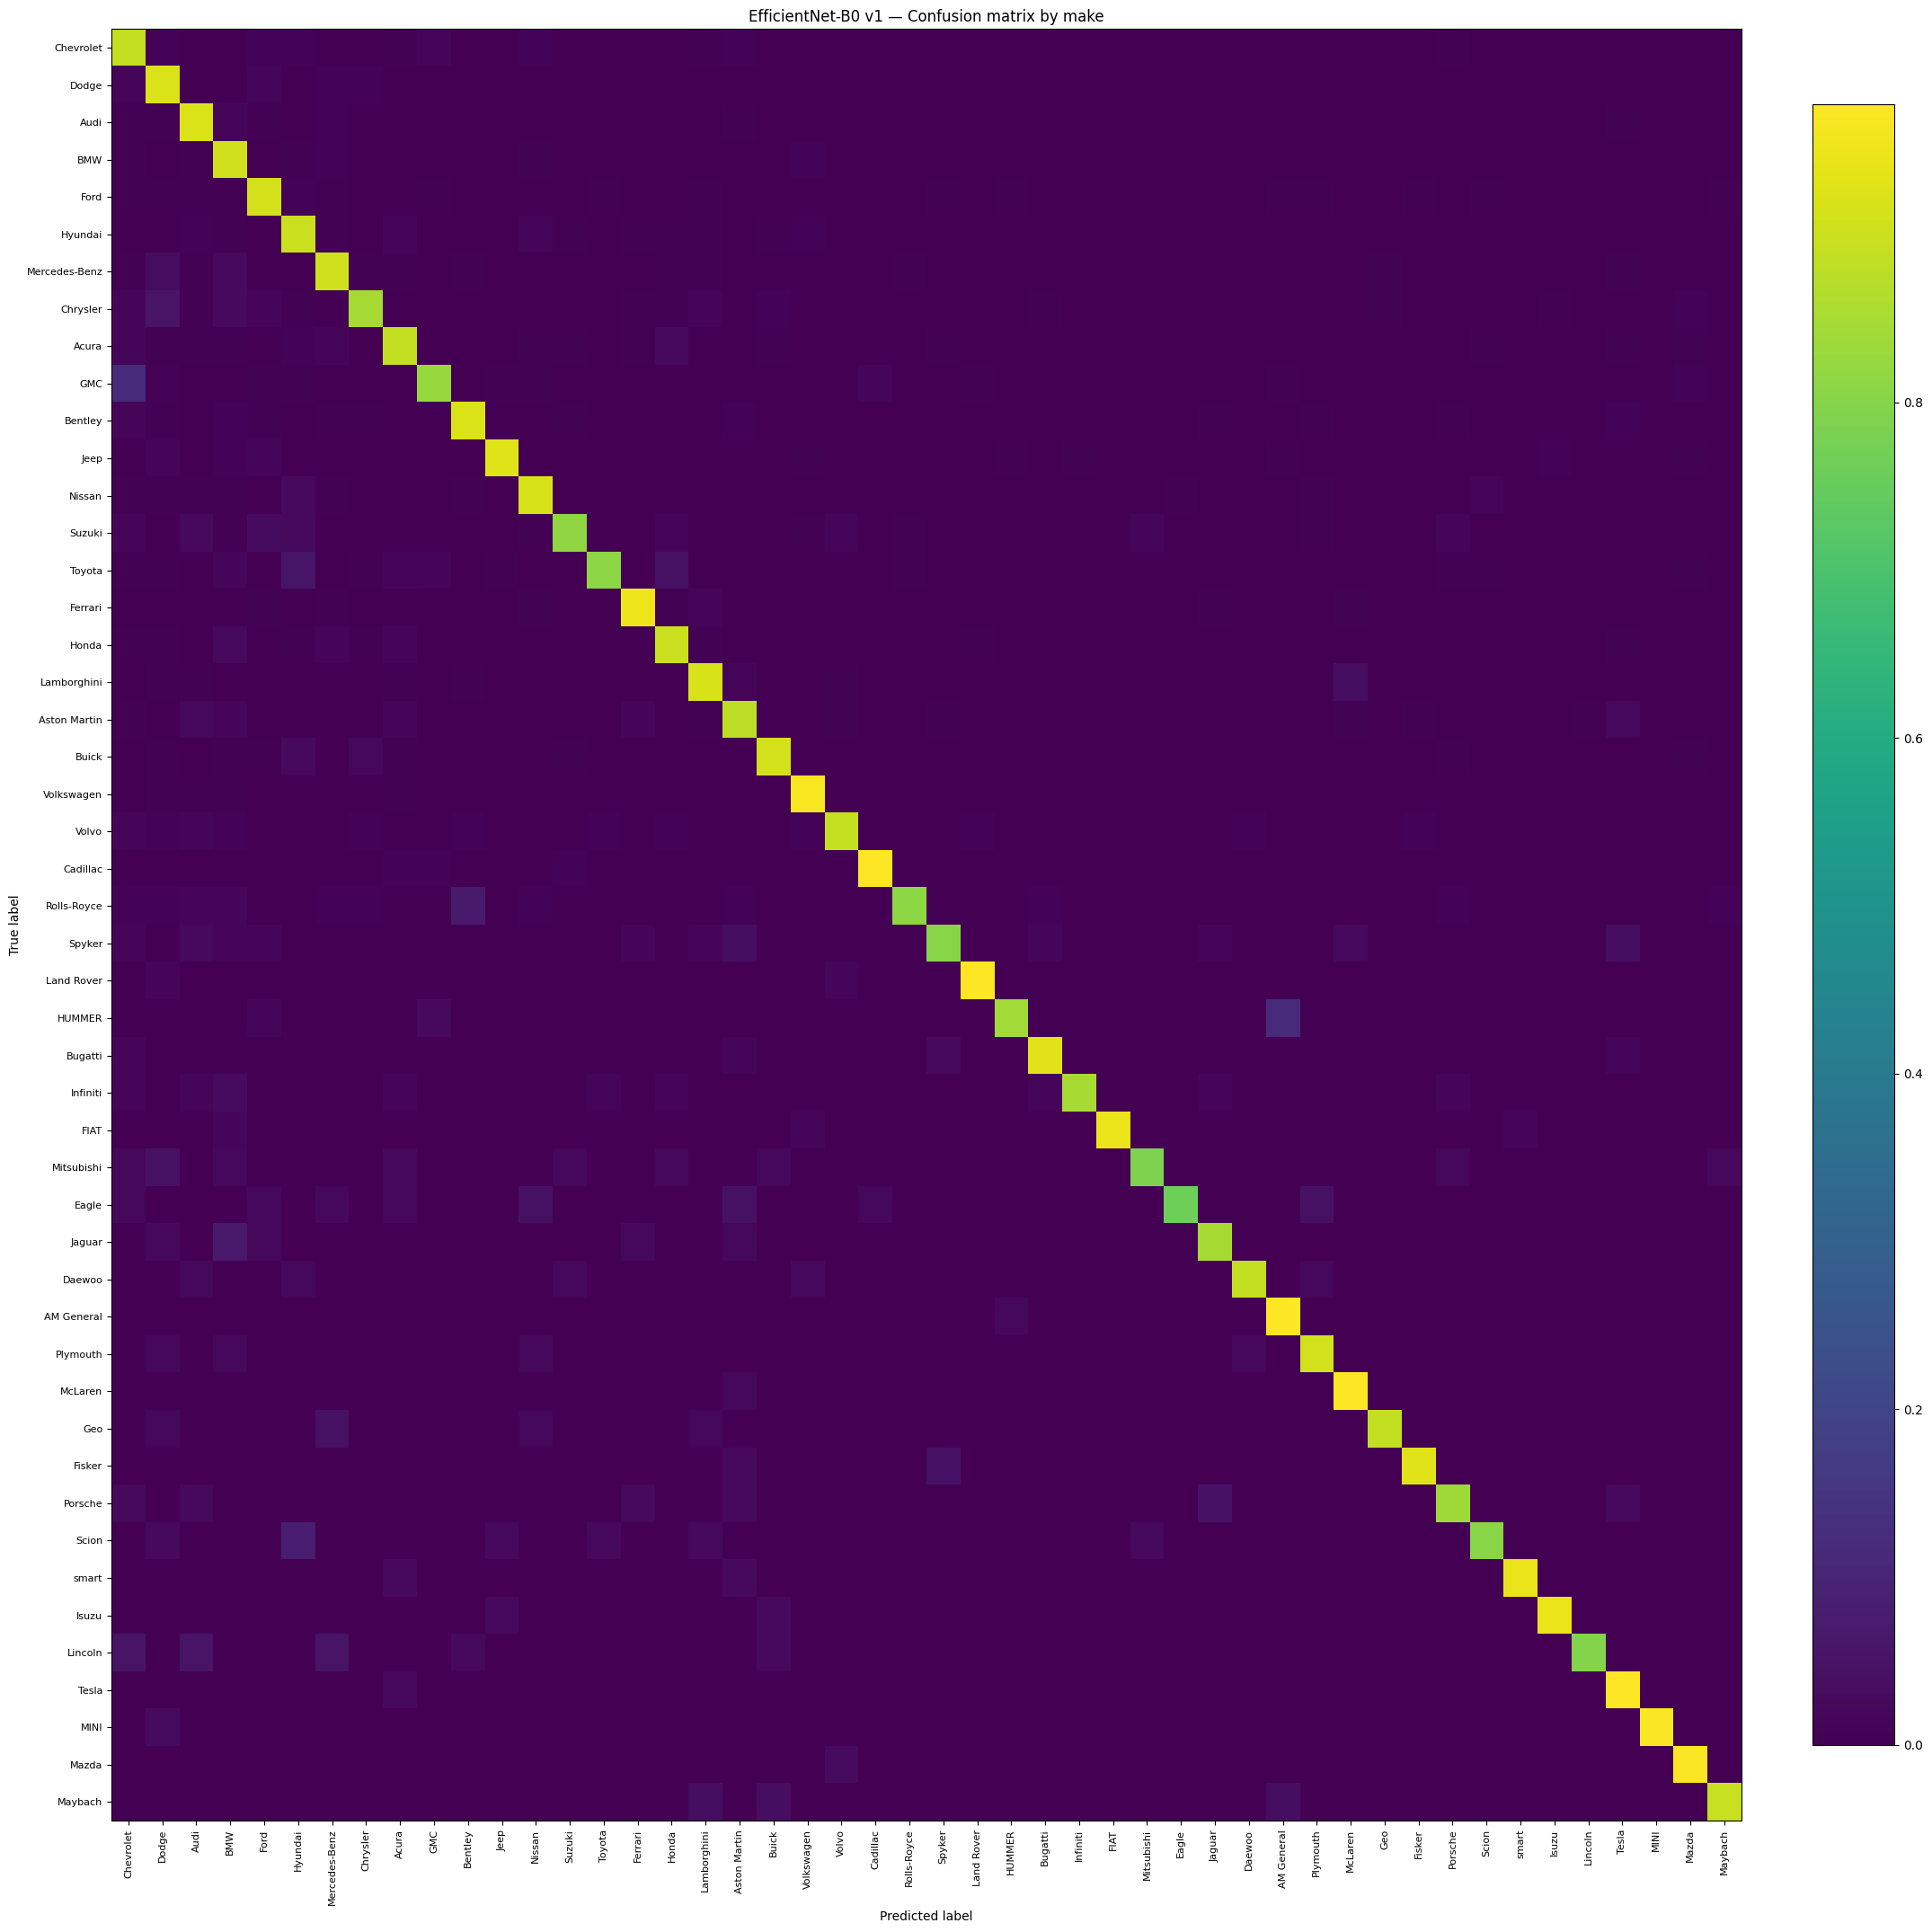

Saved: /content/drive/MyDrive/twincar/reports/efficientnet_b0_v1/confusion_matrix_make.png


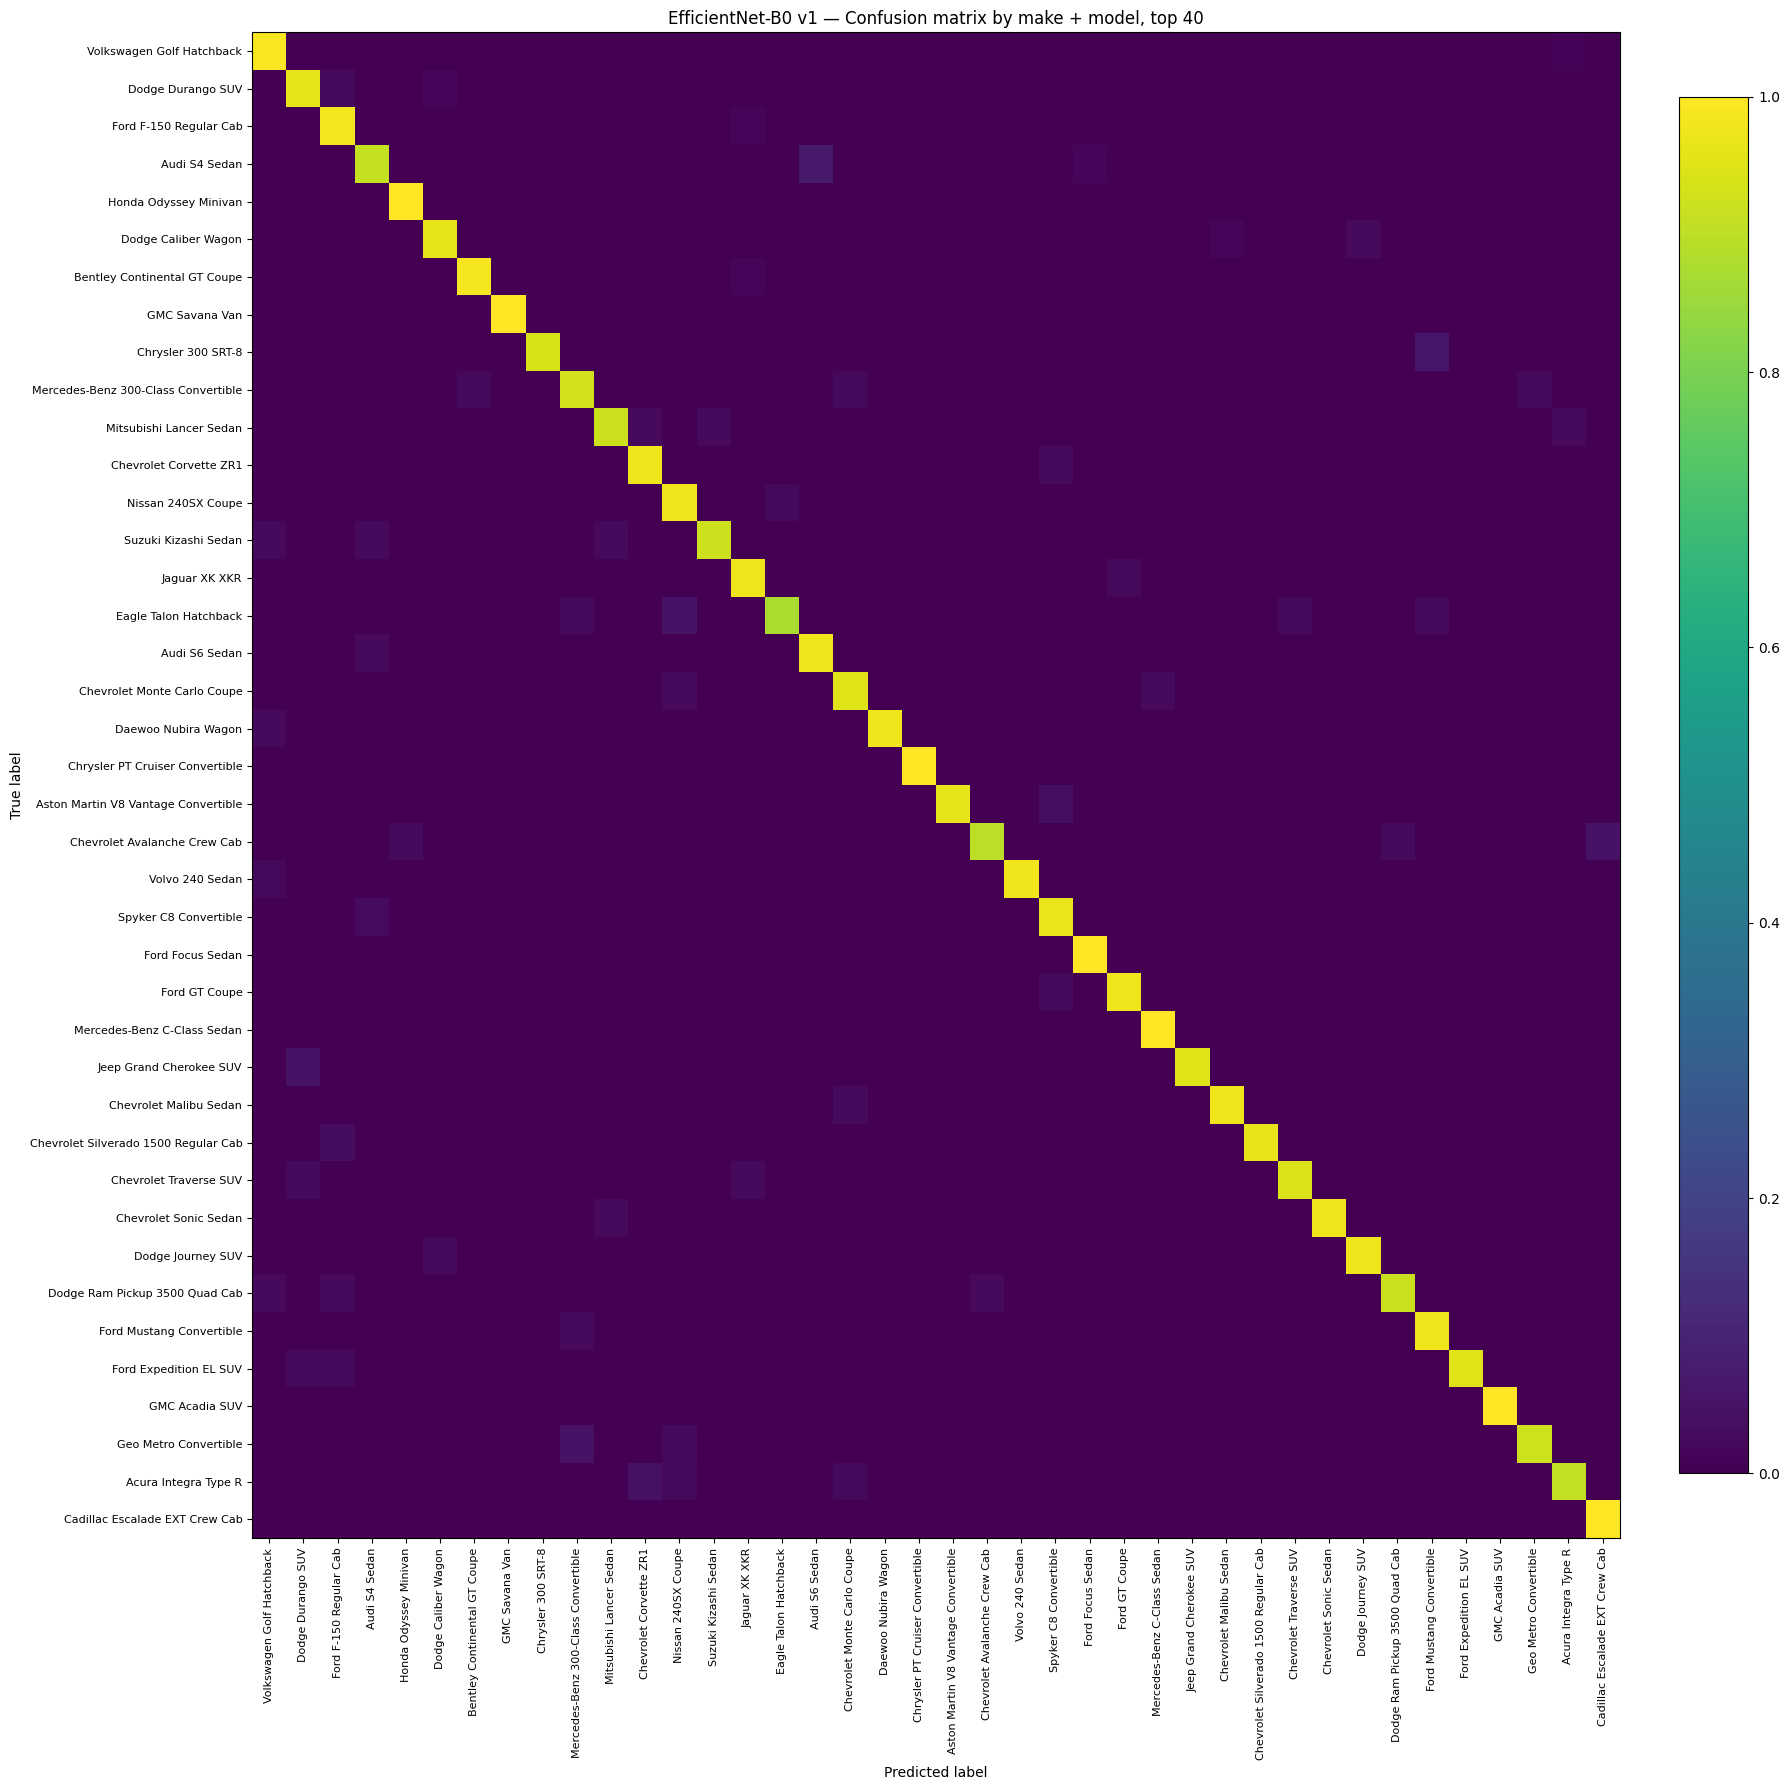

Saved: /content/drive/MyDrive/twincar/reports/efficientnet_b0_v1/confusion_matrix_make_model_top40.png


In [15]:
def save_confusion_matrix_csv(y_true_labels, y_pred_labels, labels, output_path):
    cm = confusion_matrix(y_true_labels, y_pred_labels, labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    cm_df.to_csv(output_path)
    return cm_df

def plot_confusion_matrix_top_labels(y_true_labels, y_pred_labels, title, output_path, max_labels=30):
    y_true_series = pd.Series(y_true_labels)
    top_labels = y_true_series.value_counts().head(max_labels).index.tolist()

    mask = y_true_series.isin(top_labels).to_numpy()
    true_filtered = np.array(y_true_labels)[mask]
    pred_filtered = np.array(y_pred_labels)[mask]

    cm = confusion_matrix(true_filtered, pred_filtered, labels=top_labels)
    cm_normalized = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    fig_width = max(10, len(top_labels) * 0.45)
    fig_height = max(8, len(top_labels) * 0.45)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    im = ax.imshow(cm_normalized, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(range(len(top_labels)))
    ax.set_yticks(range(len(top_labels)))
    ax.set_xticklabels(top_labels, rotation=90, fontsize=8)
    ax.set_yticklabels(top_labels, fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)

exact_labels = sorted(predictions_df["true_class"].unique().tolist())
make_model_labels = sorted(predictions_df["true_make_model"].unique().tolist())
make_labels = sorted(predictions_df["true_make"].unique().tolist())

exact_cm_path = REPORTS_DIR / "confusion_matrix_exact_class.csv"
make_model_cm_path = REPORTS_DIR / "confusion_matrix_make_model.csv"
make_cm_path = REPORTS_DIR / "confusion_matrix_make.csv"

save_confusion_matrix_csv(
    predictions_df["true_class"],
    predictions_df["pred_class"],
    exact_labels,
    exact_cm_path,
)

save_confusion_matrix_csv(
    predictions_df["true_make_model"],
    predictions_df["pred_make_model"],
    make_model_labels,
    make_model_cm_path,
)

save_confusion_matrix_csv(
    predictions_df["true_make"],
    predictions_df["pred_make"],
    make_labels,
    make_cm_path,
)

print("Saved CSV confusion matrices:")
print("-", exact_cm_path)
print("-", make_model_cm_path)
print("-", make_cm_path)

plot_confusion_matrix_top_labels(
    predictions_df["true_make"],
    predictions_df["pred_make"],
    f"{MODEL_DISPLAY_NAME} — Confusion matrix by make",
    REPORTS_DIR / "confusion_matrix_make.png",
    max_labels=50,
)

plot_confusion_matrix_top_labels(
    predictions_df["true_make_model"],
    predictions_df["pred_make_model"],
    f"{MODEL_DISPLAY_NAME} — Confusion matrix by make + model, top 40",
    REPORTS_DIR / "confusion_matrix_make_model_top40.png",
    max_labels=40,
)


## Top confusion pairs

This is often more useful than a large confusion matrix.

It answers:

> Which labels does the model most often confuse?


In [16]:
def top_confusion_pairs(df, true_col, pred_col, level_name, top_n=30):
    wrong = df[df[true_col] != df[pred_col]].copy()

    if wrong.empty:
        return pd.DataFrame(columns=[f"true_{level_name}", f"pred_{level_name}", "count"])

    result = (
        wrong
        .groupby([true_col, pred_col])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(top_n)
        .rename(columns={true_col: f"true_{level_name}", pred_col: f"pred_{level_name}"})
        .reset_index(drop=True)
    )

    return result

exact_confusions = top_confusion_pairs(predictions_df, "true_class", "pred_class", "class")
make_model_confusions = top_confusion_pairs(predictions_df, "true_make_model", "pred_make_model", "make_model")
make_confusions = top_confusion_pairs(predictions_df, "true_make", "pred_make", "make")

exact_confusions.to_csv(REPORTS_DIR / "top_confusions_exact_class.csv", index=False)
make_model_confusions.to_csv(REPORTS_DIR / "top_confusions_make_model.csv", index=False)
make_confusions.to_csv(REPORTS_DIR / "top_confusions_make.csv", index=False)

print("Top exact-class confusions:")
display(exact_confusions.head(15))

print("Top make + model confusions:")
display(make_model_confusions.head(15))

print("Top make confusions:")
display(make_confusions.head(15))


Top exact-class confusions:


,true_class,pred_class,count
0,BMW 6 Series Convertible 2007,BMW M6 Convertible 2010,15
1,Dodge Caliber Wagon 2012,Dodge Caliber Wagon 2007,11
2,Chevrolet Silverado 1500 Regular Cab 2012,Chevrolet Silverado 2500HD Regular Cab 2012,10
3,GMC Savana Van 2012,Chevrolet Express Van 2007,10
4,Chevrolet Tahoe Hybrid SUV 2012,Chevrolet Avalanche Crew Cab 2012,10
5,Audi V8 Sedan 1994,Audi 100 Sedan 1994,10
6,Audi S5 Coupe 2012,Audi A5 Coupe 2012,9
7,Lamborghini Aventador Coupe 2012,Lamborghini Reventon Coupe 2008,9
8,Chevrolet Silverado 2500HD Regular Cab 2012,Chevrolet Silverado 1500 Regular Cab 2012,9
9,HUMMER H2 SUT Crew Cab 2009,AM General Hummer SUV 2000,9


Top make + model confusions:


,true_make_model,pred_make_model,count
0,BMW 6 Series Convertible,BMW M6 Convertible,15
1,Chevrolet Tahoe Hybrid SUV,Chevrolet Avalanche Crew Cab,10
2,GMC Savana Van,Chevrolet Express Van,10
3,Audi V8 Sedan,Audi 100 Sedan,10
4,Chevrolet Silverado 1500 Regular Cab,Chevrolet Silverado 2500HD Regular Cab,10
5,Lamborghini Aventador Coupe,Lamborghini Reventon Coupe,9
6,Audi S5 Coupe,Audi A5 Coupe,9
7,HUMMER H2 SUT Crew Cab,AM General Hummer SUV,9
8,Chevrolet Express Van,Chevrolet Express Cargo Van,9
9,Chevrolet Express Cargo Van,Chevrolet Express Van,9


Top make confusions:


,true_make,pred_make,count
0,GMC,Chevrolet,27
1,Chevrolet,GMC,15
2,Chrysler,Dodge,13
3,HUMMER,AM General,10
4,Audi,BMW,10
5,Toyota,Hyundai,9
6,Dodge,Chevrolet,9
7,Dodge,Ford,9
8,Chevrolet,Ford,8
9,Chevrolet,Nissan,8


## Confidence and error analysis

This helps answer:

- Is the model confidently wrong?
- Are wrong predictions usually low-confidence?
- Can confidence be used to flag uncertain predictions for human review?

For a real TwinCar system, low-confidence predictions could be sent to manual inspection instead of being trusted automatically.


,correct_exact,count,mean,median,min,max
0,wrong,1354,0.371501,0.303833,0.041382,0.994141
1,correct,6646,0.747296,0.846436,0.048157,0.999023


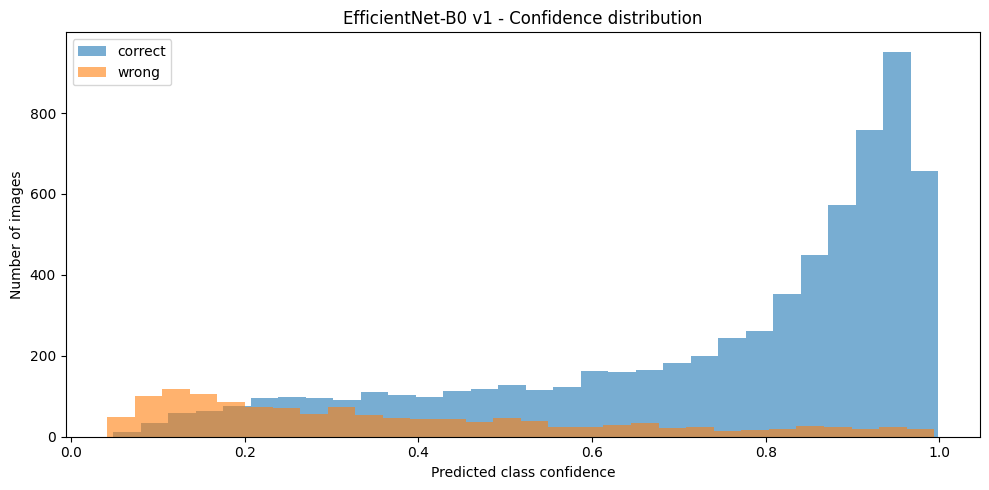

Saved confidence plot to: /content/drive/MyDrive/twincar/reports/efficientnet_b0_v1/confidence_distribution.png


In [21]:
confidence_summary = (
    predictions_df
    .groupby("correct_exact")["confidence"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)

confidence_summary["correct_exact"] = confidence_summary["correct_exact"].map({
    True: "correct",
    False: "wrong",
})

confidence_summary_path = REPORTS_DIR / "confidence_summary.csv"
confidence_summary.to_csv(confidence_summary_path, index=False)

display(confidence_summary)

plt.figure(figsize=(10, 5))
plt.hist(predictions_df.loc[predictions_df["correct_exact"], "confidence"], bins=30, alpha=0.6, label="correct")
plt.hist(predictions_df.loc[~predictions_df["correct_exact"], "confidence"], bins=30, alpha=0.6, label="wrong")
plt.title(f"{MODEL_DISPLAY_NAME} - Confidence distribution")
plt.xlabel("Predicted class confidence")
plt.ylabel("Number of images")
plt.legend()
plt.tight_layout()

confidence_plot_path = REPORTS_DIR / "confidence_distribution.png"
plt.savefig(confidence_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved confidence plot to:", confidence_plot_path)


## Visualize misclassified examples

The grid displays high-confidence wrong predictions first, because these are the most interesting mistakes.


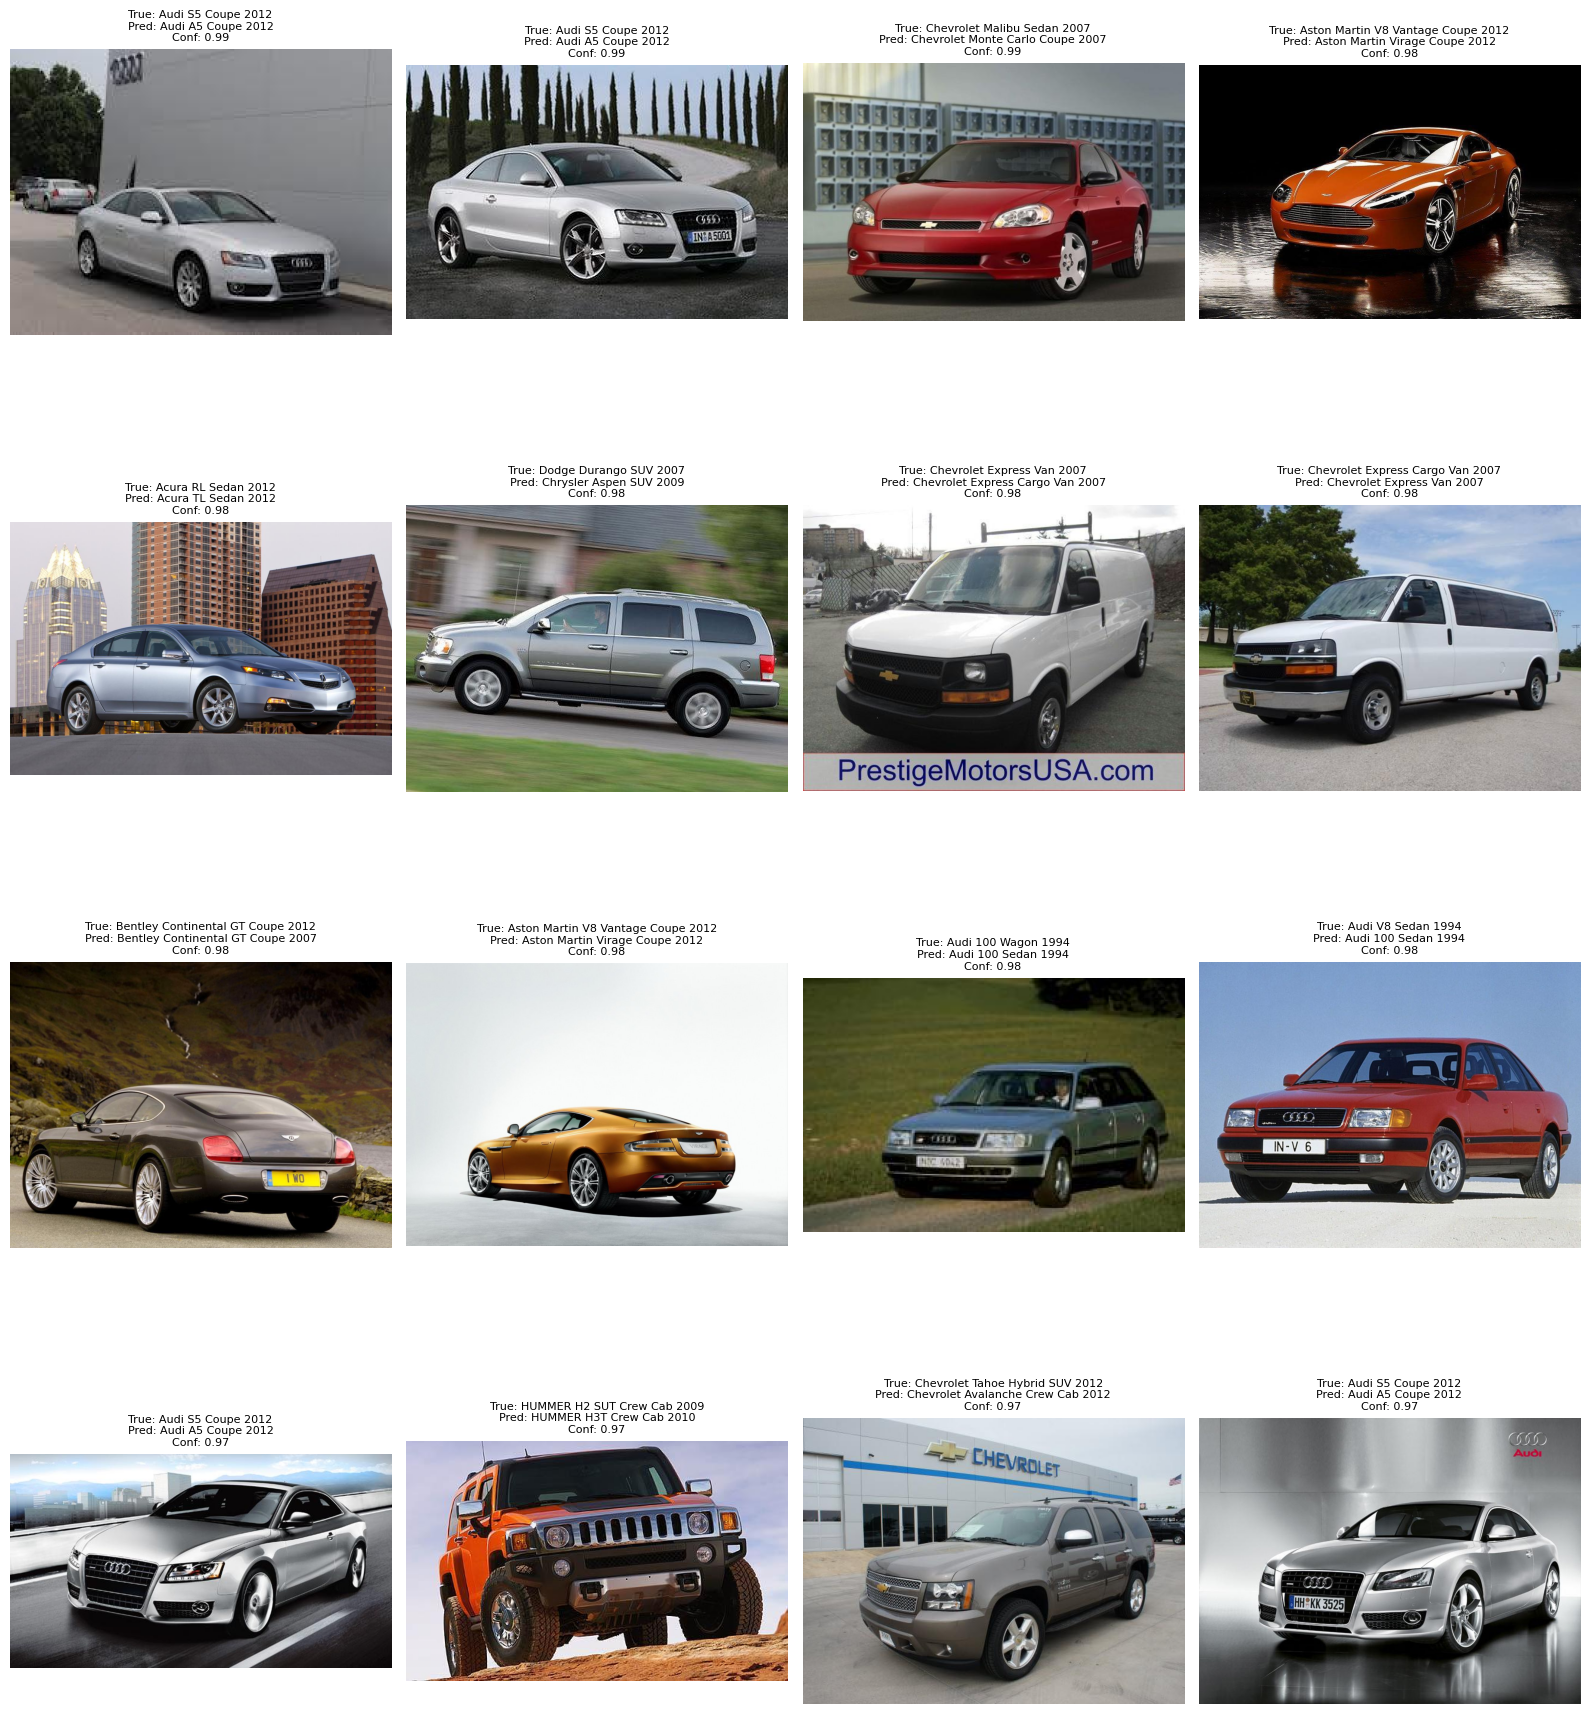

Saved misclassified examples to: /content/drive/MyDrive/twincar/reports/efficientnet_b0_v1/misclassified_examples.png


In [18]:
from PIL import Image

def show_misclassified_examples(df, n=16, sort_by="confidence"):
    wrong = df[~df["correct_exact"]].copy()

    if wrong.empty:
        print("No misclassified examples found.")
        return

    wrong = wrong.sort_values(sort_by, ascending=False).head(n)

    n_cols = 4
    n_rows = int(np.ceil(len(wrong) / n_cols))

    plt.figure(figsize=(4 * n_cols, 4.8 * n_rows))

    for plot_idx, (_, row) in enumerate(wrong.iterrows(), start=1):
        img = Image.open(row["image_path"]).convert("RGB")

        ax = plt.subplot(n_rows, n_cols, plot_idx)
        ax.imshow(img)
        ax.axis("off")

        title = (
            f"True: {row['true_class']}\n"
            f"Pred: {row['pred_class']}\n"
            f"Conf: {row['confidence']:.2f}"
        )
        ax.set_title(title, fontsize=8)

    plt.tight_layout()
    output_path = REPORTS_DIR / "misclassified_examples.png"
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved misclassified examples to:", output_path)

show_misclassified_examples(predictions_df, n=16)


## Training curves from checkpoint/history




Loaded history from: /content/drive/MyDrive/twincar/models/last_checkpoint.pt


,train_loss,val_loss,train_top1,val_top1,val_top5,lr
0,4.657584,3.776826,0.133440,0.232730,0.546053,0.0003
1,2.822950,2.580318,0.499637,0.513980,0.813322,0.0003
2,1.914972,2.117384,0.746043,0.657895,0.882401,0.0003
3,1.569841,1.942950,0.842892,0.698191,0.910362,0.0003
4,1.355770,1.896623,0.910121,0.705592,0.914474,0.0003


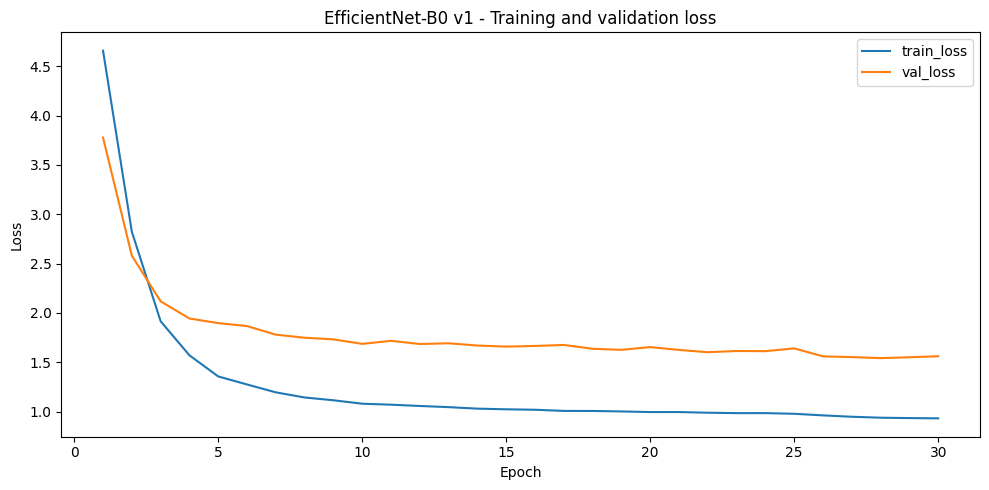

Saved loss curves to: /content/drive/MyDrive/twincar/reports/efficientnet_b0_v1/loss_curves.png


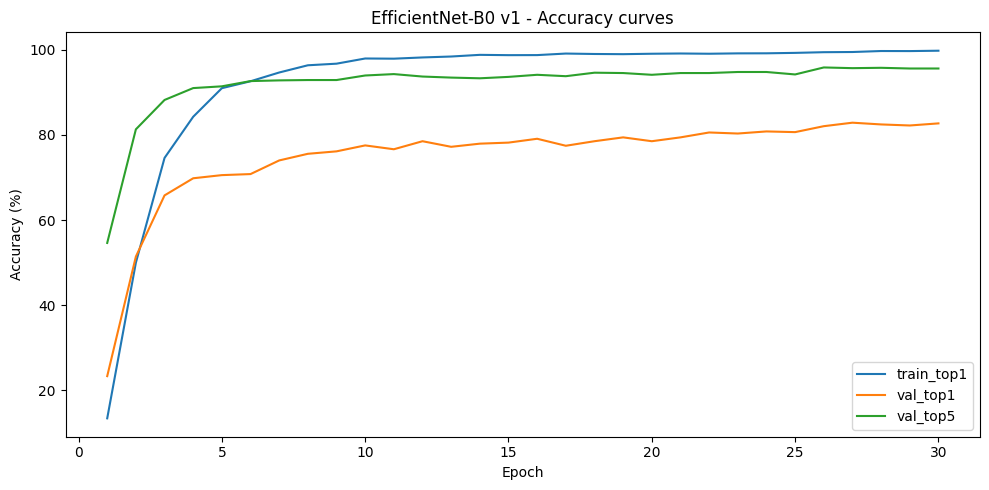

Saved accuracy curves to: /content/drive/MyDrive/twincar/reports/efficientnet_b0_v1/accuracy_curves.png


In [22]:
history = None

possible_history_csv_paths = [
    MODEL_DIR / "training_history.csv",
    MODEL_DIR / "history.csv",
    PROJECT_DIR / "models" / "training_history.csv",
    PROJECT_DIR / "models" / "history.csv",
]

history_csv_path = next((p for p in possible_history_csv_paths if p.exists()), None)

if history_csv_path is not None:
    history_df = pd.read_csv(history_csv_path)
    print("Loaded history CSV:", history_csv_path)
else:
    possible_checkpoint_history_paths = [
        MODEL_DIR / "last_checkpoint.pt",
        PROJECT_DIR / "models" / "last_checkpoint.pt",
    ]

    last_checkpoint_path = next((p for p in possible_checkpoint_history_paths if p.exists()), None)

    if last_checkpoint_path is not None:
        try:
            last_ckpt = torch.load(last_checkpoint_path, map_location="cpu")
            if isinstance(last_ckpt, dict) and "history" in last_ckpt:
                history = last_ckpt["history"]
                history_df = pd.DataFrame(history)
                print("Loaded history from:", last_checkpoint_path)
            else:
                history_df = None
                print("last_checkpoint.pt found, but no history key.")
        except Exception as e:
            history_df = None
            print("Could not load checkpoint history:", e)
    else:
        history_df = None
        print("No training history found.")

if history_df is None:
    print("Skipping training curve plot.")
else:
    display(history_df.head())

    x = np.arange(1, len(history_df) + 1)

    plt.figure(figsize=(10, 5))
    for col in ["train_loss", "val_loss"]:
        if col in history_df.columns:
            plt.plot(x, history_df[col], label=col)

    plt.title(f"{MODEL_DISPLAY_NAME} - Training and validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()

    loss_curve_path = REPORTS_DIR / "loss_curves.png"
    plt.savefig(loss_curve_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved loss curves to:", loss_curve_path)

    plt.figure(figsize=(10, 5))
    for col in ["train_top1", "val_top1", "val_top5", "train_acc", "val_acc"]:
        if col in history_df.columns:
            values = history_df[col]
            if pd.Series(values).max() <= 1.0:
                values = pd.Series(values) * 100
            plt.plot(x, values, label=col)

    plt.title(f"{MODEL_DISPLAY_NAME} - Accuracy curves")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.tight_layout()

    acc_curve_path = REPORTS_DIR / "accuracy_curves.png"
    plt.savefig(acc_curve_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved accuracy curves to:", acc_curve_path)


## Summary

The model was evaluated on the held-out test set. We report exact class metrics, but also aggregate by make and make + model to make the results easier to interpret.


In [20]:
final_summary = {
    "model_name": MODEL_NAME,
    "model_display_name": MODEL_DISPLAY_NAME,
    "checkpoint_name": CHECKPOINT_NAME,
    "checkpoint_path": str(MODEL_PATH),
    "test_images": len(predictions_df),
    "exact_classes": num_classes,
    "exact_top1_accuracy": metrics["exact_top1_accuracy"],
    "exact_top5_accuracy": metrics["exact_top5_accuracy"],
    "exact_macro_precision": metrics["exact_precision_macro"],
    "exact_macro_recall": metrics["exact_recall_macro"],
    "exact_macro_f1": metrics["exact_f1_macro"],
    "exact_weighted_f1": metrics["exact_f1_weighted"],
    "make_model_accuracy": metrics["make_model_accuracy"],
    "make_accuracy": metrics["make_accuracy"],
    "test_loss": metrics["test_loss"],
    "model_file_size_mb": metrics["model_file_size_mb"],
    "images_per_second_full_eval": metrics["images_per_second"],
}

final_summary_df = pd.DataFrame([final_summary])
final_summary_path = REPORTS_DIR / "final_readme_summary.csv"
final_summary_df.to_csv(final_summary_path, index=False)

display(final_summary_df.T.rename(columns={0: "value"}))

print("Saved final summary to:", final_summary_path)
print("\nAll evaluation files were saved in:")
print(REPORTS_DIR)


,value
model_name,efficientnet_b0_v1
model_display_name,EfficientNet-B0 v1
checkpoint_name,best_model.pt
checkpoint_path,/content/drive/MyDrive/twincar/models/best_mod...
test_images,8000
exact_classes,195
exact_top1_accuracy,0.83075
exact_top5_accuracy,0.952
exact_macro_precision,0.83913
exact_macro_recall,0.830626


Saved final summary to: /content/drive/MyDrive/twincar/reports/efficientnet_b0_v1/final_readme_summary.csv

All evaluation files were saved in:
/content/drive/MyDrive/twincar/reports/efficientnet_b0_v1
